In [1]:
import matplotlib.pyplot as plt
import akshare as ak
import pandas as pd

# Step 1: Set character and symbol display
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# Step 2: Load ak Data
def load_hist_data():
    hist_df = ak.energy_oil_hist()     
    print("\nHistorical price adjustment data:")
    print(hist_df.head(2))    
    return hist_df

def load_guangxi_data(hist_df):
    date_column = hist_df.columns[0] 
    #price_column_92 = "汽油价格"  
    hist_df['Date'] = pd.to_datetime(hist_df[date_column], errors='coerce')        
    # Filter recent data (starting from 2024)
    start_date = pd.Timestamp('2024-01-01')
    mask = hist_df['Date'] >= start_date
    filtered_dates_df = hist_df[mask].copy()             
    # Get data for Guangxi 
    guangxi_prices = []
    valid_dates = []           
    for i, row in filtered_dates_df.iterrows():
        adjust_date = row['Date']            
        if pd.isna(adjust_date):
            continue                
        date_str = adjust_date.strftime('%Y%m%d')            
        try:
            detail_df = ak.energy_oil_detail(date=date_str)
            region_col = None
            price_col = None            
            for col in detail_df.columns:
                col_str = str(col)
                if '地区' in col_str or 'area' in col_str.lower() or 'province' in col_str.lower():
                    region_col = col
                if '92' in col_str or '92#' in col_str or '92号' in col_str or '汽油' in col_str:
                    price_col = col
            
            if region_col and price_col:
                # Find Guangxi data
                mask = detail_df[region_col].astype(str).str.contains('广西', na=False)
                if mask.any():
                    price_value = detail_df.loc[mask, price_col].iloc[0]
                    try:
                        price_num = float(price_value)
                        guangxi_prices.append(price_num)
                        valid_dates.append(adjust_date)
                    except:
                        print(f"  ✗ Price conversion failed: {price_value}")
                else:
                    print(f"  ✗ No data found for the Guangxi region")
            else:
                print(f"  ✗ Required column not found")
                
        except Exception as e:
            continue
    return valid_dates, guangxi_prices   

hist_df = load_hist_data()
valid_dates, guangxi_prices = load_guangxi_data(hist_df)
print(hist_df.head())
print(valid_dates)
print(guangxi_prices)



Historical price adjustment data:
         调整日期  汽油价格  柴油价格   汽油涨跌   柴油涨跌
0  2000-06-06  2935  2430    NaN    NaN
1  2000-07-15  3135  2610  200.0  180.0
         调整日期  汽油价格  柴油价格   汽油涨跌   柴油涨跌       Date
0  2000-06-06  2935  2430    NaN    NaN 2000-06-06
1  2000-07-15  3135  2610  200.0  180.0 2000-07-15
2  2000-08-18  3405  2770  270.0  160.0 2000-08-18
3  2000-09-20  3615  3070  210.0  300.0 2000-09-20
4  2000-10-20  3435  3440 -180.0  370.0 2000-10-20
[Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-18 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-05 00:00:00'), Timestamp('2024-04-02 00:00:00'), Timestamp('2024-04-17 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-16 00:00:00'), Timestamp('2024-06-14 00:00:00'), Timestamp('2024-06-28 00:00:00'), Timestamp('2024-07-12 00:00:00'), Timestamp('2024-07-26 00:00:00'), Timestamp('2024-08-09 00:00:00'), Timestamp('2024-09-06 00:00:00'), Timestamp('2024-09-21 00:00:00'), Timestamp('2024-10-11 00:00:

In [6]:
# step 3 clear data and Create analysis data 
def create_analysis_data():
    analysis_data = []
    # Standard ton-to-liter conversion factor (National Bureau of Statistics/Consumption Tax Standard: 1 ton of gasoline ≈ 1388 liters)
    TON_TO_LITER_RATIO = 1388 
    for date, guangxi_price in zip(valid_dates, guangxi_prices):
        # Obtain the corresponding national price
        national_price_row = hist_df[hist_df['Date'] == date]
        if not national_price_row.empty:
            national_price = pd.to_numeric(national_price_row.iloc[0,1], errors='coerce')
            if not pd.isna(national_price) and not pd.isna(guangxi_price):
                analysis_data.append({
                    'Date': date,
                    'National_Adjustment': national_price,
                    'Guangxi_Price': guangxi_price,
                    'Guangxi_Price(ton)': guangxi_price*TON_TO_LITER_RATIO
                })
    
    if not analysis_data:
        print("Error: No data available for analysis.")
        return []
    return analysis_data

analysis_data = create_analysis_data()
print(analysis_data)

[{'Date': Timestamp('2024-01-04 00:00:00'), 'National_Adjustment': 8830, 'Guangxi_Price': 7.6, 'Guangxi_Price(ton)': 10548.8}, {'Date': Timestamp('2024-01-18 00:00:00'), 'National_Adjustment': 8780, 'Guangxi_Price': 7.76, 'Guangxi_Price(ton)': 10770.88}, {'Date': Timestamp('2024-02-01 00:00:00'), 'National_Adjustment': 8980, 'Guangxi_Price': 7.72, 'Guangxi_Price(ton)': 10715.359999999999}, {'Date': Timestamp('2024-03-05 00:00:00'), 'National_Adjustment': 9105, 'Guangxi_Price': 7.88, 'Guangxi_Price(ton)': 10937.44}, {'Date': Timestamp('2024-04-02 00:00:00'), 'National_Adjustment': 9305, 'Guangxi_Price': 7.98, 'Guangxi_Price(ton)': 11076.24}, {'Date': Timestamp('2024-04-17 00:00:00'), 'National_Adjustment': 9505, 'Guangxi_Price': 8.14, 'Guangxi_Price(ton)': 11298.320000000002}, {'Date': Timestamp('2024-04-30 00:00:00'), 'National_Adjustment': 9435, 'Guangxi_Price': 8.3, 'Guangxi_Price(ton)': 11520.400000000001}, {'Date': Timestamp('2024-05-16 00:00:00'), 'National_Adjustment': 9200, 'Gua

In [7]:
# step 4 Calculate month-on-month growth rate 
analysis_df = pd.DataFrame(analysis_data)
analysis_df = analysis_df.sort_values('Date').reset_index(drop=True)
analysis_df.set_index('Date', inplace=True)
if len(analysis_df) > 1:
    analysis_df['National_Adjustment_MoM'] = analysis_df['National_Adjustment'].pct_change(periods=1) * 100
    analysis_df['Guangxi_Price_MoM'] = analysis_df['Guangxi_Price'].pct_change(periods=1) * 100
else:
    analysis_df['National_Adjustment_MoM'] = 0
    analysis_df['Guangxi_Price_MoM'] = 0

print(analysis_df.head())

            National_Adjustment  Guangxi_Price  Guangxi_Price(ton)  \
Date                                                                 
2024-01-04                 8830           7.60            10548.80   
2024-01-18                 8780           7.76            10770.88   
2024-02-01                 8980           7.72            10715.36   
2024-03-05                 9105           7.88            10937.44   
2024-04-02                 9305           7.98            11076.24   

            National_Adjustment_MoM  Guangxi_Price_MoM  
Date                                                    
2024-01-04                      NaN                NaN  
2024-01-18                -0.566251           2.105263  
2024-02-01                 2.277904          -0.515464  
2024-03-05                 1.391982           2.072539  
2024-04-02                 2.196595           1.269036  


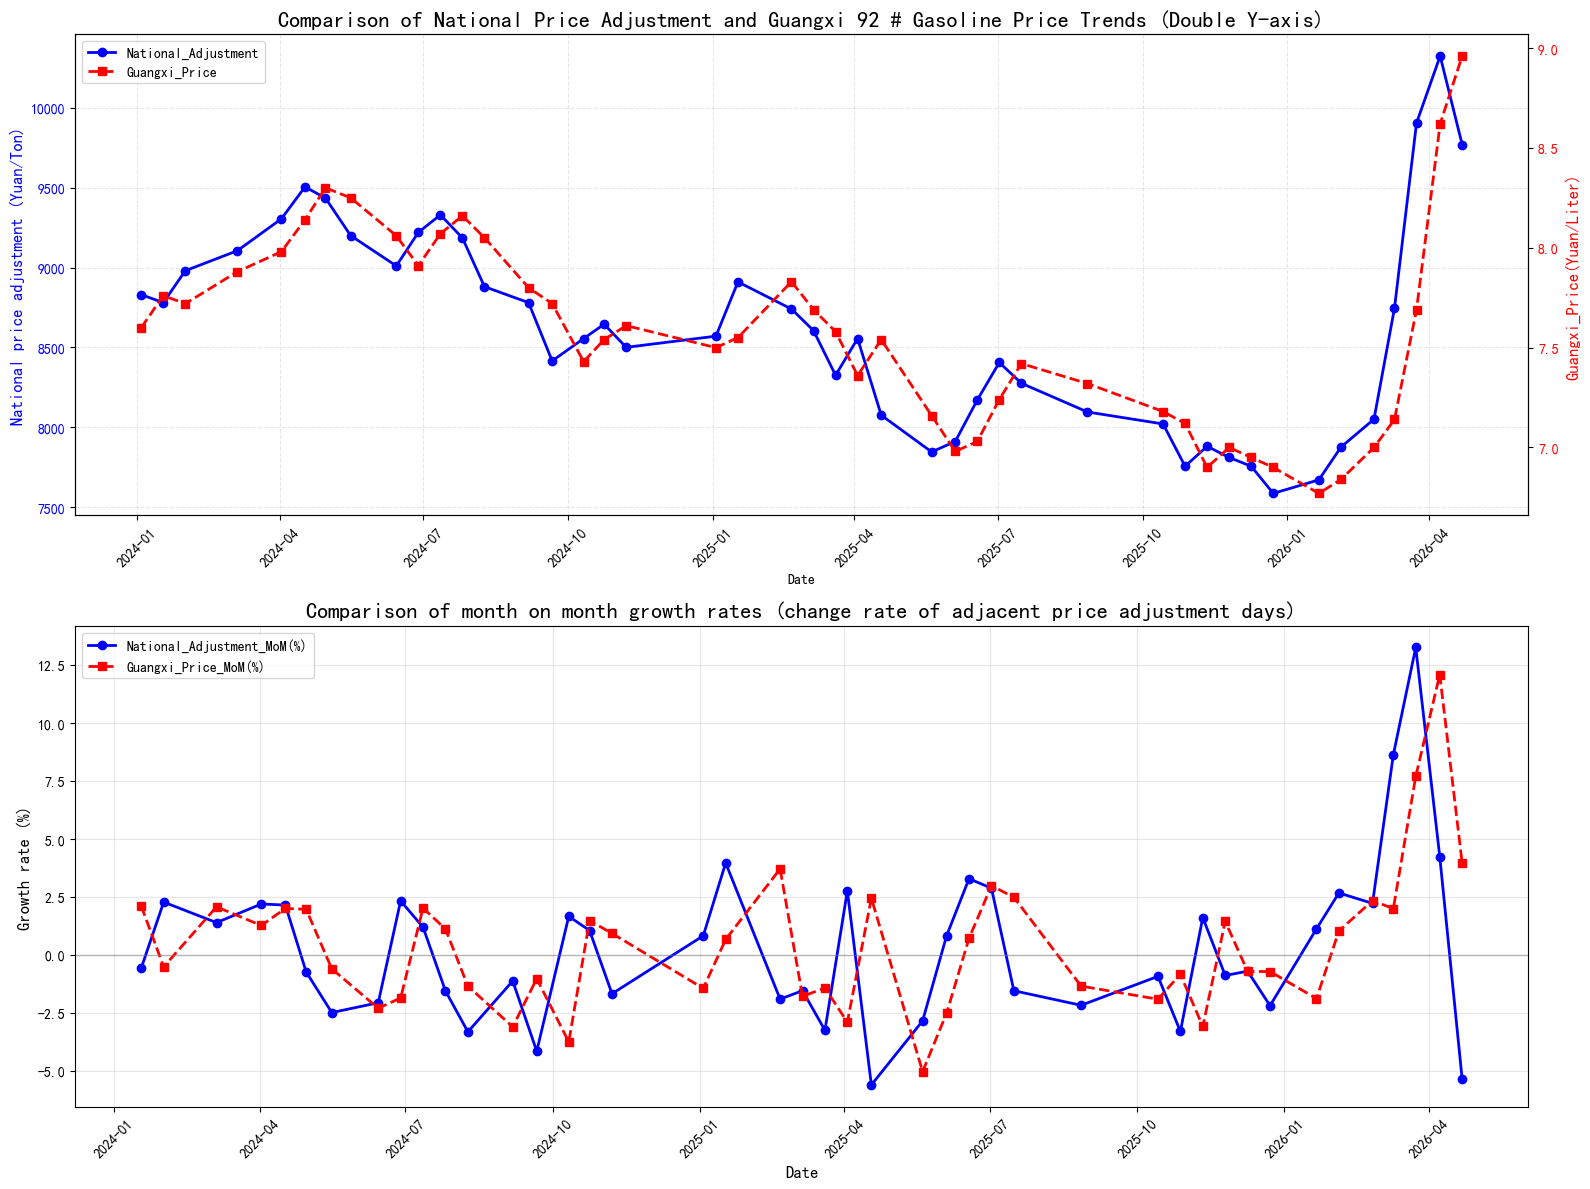

In [8]:
# step 5 Visualization – Comprehensive Charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
        
# Figure 1: Price Trends - Using Dual Y-Axis
ax1_left = ax1
ax1_right = ax1_left.twinx() 

# Draw national price adjustments (left Y-axis)
line1 = ax1_left.plot(analysis_df.index, analysis_df['National_Adjustment'], 
        marker='o', linestyle='-', linewidth=2, label='National_Adjustment', color='blue')
ax1_left.set_xlabel('Date')
ax1_left.set_ylabel('National price adjustment (Yuan/Ton)', color='blue', fontsize=12)
ax1_left.tick_params(axis='y', labelcolor='blue')

# Draw Guangxi price (right Y-axis) 
line2 = ax1_right.plot(analysis_df.index, analysis_df['Guangxi_Price'], 
        marker='s', linestyle='--', linewidth=2, label='Guangxi_Price', color='red')
ax1_right.set_ylabel('Guangxi_Price(Yuan/Liter)', color='red', fontsize=12)
ax1_right.tick_params(axis='y', labelcolor='red')

# Set title and legend 
ax1_left.set_title('Comparison of National Price Adjustment and Guangxi 92 # Gasoline Price Trends (Double Y-axis)', fontsize=16, fontweight='bold')

# Merge legend 
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1_left.legend(lines, labels, loc='upper left')

ax1_left.grid(True, alpha=0.3, linestyle='--')


# Figure 2: Month-on-Month Growth Rate
if len(analysis_df) > 1:
    ax2.plot(analysis_df.index[1:], analysis_df['National_Adjustment_MoM'].iloc[1:], 
            marker='o', linestyle='-', linewidth=2, label='National_Adjustment_MoM(%)', color='blue')
    ax2.plot(analysis_df.index[1:], analysis_df['Guangxi_Price_MoM'].iloc[1:], 
            marker='s', linestyle='--', linewidth=2, label='Guangxi_Price_MoM(%)', color='red')
    ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_title('Comparison of month on month growth rates (change rate of adjacent price adjustment days)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Growth rate (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Rotate the x-axis labels 
for ax in [ax1_left, ax2]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

In [ ]:
# step 6 Statistical information 
print(f"Analysis cycle: {analysis_df.index.min().date()} - {analysis_df.index.max().date()}")
print(f"Number of data points: {len(analysis_df)}")
print(f"\nPrice Statistics:")
print(f"National average price adjustment: {analysis_df['National_Adjustment'].mean():.3f} 元/吨")
print(f"National price adjustment range: {analysis_df['National_Adjustment'].min():.3f} - {analysis_df['National_Adjustment'].max():.3f} 元/升")
print(f"Average price in Guangxi: {analysis_df['Guangxi_Price'].mean():.3f} 元/升")
print(f"Price Range in Guangxi: {analysis_df['Guangxi_Price'].min():.3f} - {analysis_df['Guangxi_Price'].max():.3f} 元/升")

if len(analysis_df) > 0:
    price_diff = analysis_df['Guangxi_Price(ton)'] - analysis_df['National_Adjustment']
    print(f"\nPrice difference analysis:")
    print(f"Average spread : {price_diff.mean():.3f} Yuan/Ton")
    print(f"Max price difference: {price_diff.max():.3f} Yuan/Ton")
    print(f"Min price difference: {price_diff.min():.3f} Yuan/Ton")
    print(f"Days of positive price difference: {sum(price_diff > 0)} day")
    print(f"Negative price difference days: {sum(price_diff < 0)} day")
    print(f"Zero price difference days: {sum(price_diff == 0)} day")

if len(analysis_df) > 1:
    print(f"\nMonth on month growth rate statistics:")
    # Exclude the first data point (calculate the growth rate from the second point onwards).
    ring_ratio_national = analysis_df['National_Adjustment_MoM'].iloc[1:]
    ring_ratio_guangxi = analysis_df['Guangxi_Price_MoM'].iloc[1:]
    if not ring_ratio_national.empty:
        print(f"National average month on month price adjustment: {ring_ratio_national.mean():.2f}%")
        print(f"Average month on month price in Guangxi: {ring_ratio_guangxi.mean():.2f}%")
        print(f"National price adjustment range on a month on month basis: {ring_ratio_national.min():.2f}% to {ring_ratio_national.max():.2f}%")
        print(f"Guangxi price range on a month on month basis: {ring_ratio_guangxi.min():.2f}% to {ring_ratio_guangxi.max():.2f}%")
        
        # Output detailed month-over-month changes
        print(f"\nDetailed month on month changes (adjacent price adjustment dates):")
        for i in range(1, len(analysis_df)):
            date = analysis_df.index[i]
            prev_date = analysis_df.index[i-1]
            national_change = analysis_df['National_Adjustment_MoM'].iloc[i]
            guangxi_change = analysis_df['Guangxi_Price_MoM'].iloc[i]
            print(f"  {prev_date.date()} → {date.date()}: National{national_change:+.2f}%, Guangxi{guangxi_change:+.2f}%")

# Calculate dynamic spread
analysis_df['Price_difference'] = analysis_df['Guangxi_Price(ton)'] - analysis_df['National_Adjustment']
# Reverse-engineering cost structure (assuming minimum price spread equals fixed costs)
fixed_cost_estimate = analysis_df['Price_difference'].min()
analysis_df['Volatility_premium'] = analysis_df['Price_difference'] - fixed_cost_estimate
# Market Efficiency: Calculate the Up/Downside Capture Ratio
analysis_df['National_price_fluctuations'] = analysis_df['National_Adjustment'].diff()
analysis_df['Guangxi_price_fluctuations'] = analysis_df['Guangxi_Price(ton)'].diff()
analysis_df['Tracking_Coefficient'] = analysis_df['Guangxi_price_fluctuations'] / analysis_df['National_price_fluctuations']
print(analysis_df)
# 4. In-depth Analysis
print(f"[In-depth Analysis]")
print(f"Estimate Guangxi's fixed logistics/operating costs to be approximately: {fixed_cost_estimate:.3f} Yuan/Ton")
print(f"The maximum volatility premium appears in: {analysis_df['Volatility_premium'].idxmax().strftime('%Y-%m')},premium {analysis_df['Volatility_premium'].max():.3f} Yuan")
print(f"Average Tracking Coefficient: {analysis_df['Tracking_Coefficient'].mean():.2f} (The closer to 1, the more efficient the market. )")

Analysis cycle: 2024-01-04 - 2026-04-22
Number of data points: 44

Price Statistics:
National average price adjustment: 8620.114 元/吨
National price adjustment range: 7585.000 - 10325.000 元/升
Average price in Guangxi: 7.574 元/升
Price Range in Guangxi: 6.770 - 8.960 元/升

Price difference analysis:
Average spread : 1892.409 Yuan/Ton
Max price difference: 2666.480 Yuan/Ton
Min price difference: 768.720 Yuan/Ton
Days of positive price difference: 44 day
Negative price difference days: 0 day
Zero price difference days: 0 day

Month on month growth rate statistics:
National average month on month price adjustment: 0.29%
Average month on month price in Guangxi: 0.43%
National price adjustment range on a month on month basis: -5.61% to 13.26%
Guangxi price range on a month on month basis: -5.04% to 12.09%

Detailed month on month changes (adjacent price adjustment dates):
  2024-01-04 → 2024-01-18: National-0.57%, Guangxi+2.11%
  2024-01-18 → 2024-02-01: National+2.28%, Guangxi-0.52%
  2024-02-